In [1]:
!pip install -q transformers datasets peft trl bitsandbytes accelerate
!pip install -q sentencepiece protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.5 MB/s eta 0:00:00


# Imports and Configuration

In [12]:
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
from datasets import load_dataset, Dataset
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
print(f"GPU name        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU name        : Tesla T4


In [13]:
#   Central Configuration

# Change these values to adapt the notebook to your use case

MODEL_NAME      = "microsoft/phi-2"       # Base model
DATASET_NAME    = "tatsu-lab/alpaca"       # HuggingFace dataset (or we can use custom)
OUTPUT_DIR      = "./finetuned-model"      # Where to save the trained model
MAX_SEQ_LEN     = 256                      # Max token length per sample
NUM_SAMPLES     = 500                     # Subset size (use None for full dataset)

# LoRA hyperparameters
LORA_R          = 16       # Rank
LORA_ALPHA      = 32       # Scaling factor (usually 2x rank)
LORA_DROPOUT    = 0.05     # Regularization

# Training hyperparameters
EPOCHS          = 3
BATCH_SIZE      = 8
GRAD_ACCUM      = 2        # Effective batch = BATCH_SIZE * GRAD_ACCUM = 16
LEARNING_RATE   = 2e-4
# ──────────────────────────────────────────────────────────────────────────────

# Load Base Model with 4-bit Quantization (QLoRA)

In [14]:
from transformers import AutoConfig


# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)
config.pad_token_id = tokenizer.eos_token_id

# Load model using the patched config
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    config=config,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

model = prepare_model_for_kbit_training(model)

print(f"Model loaded: {MODEL_NAME}")
print(f"Trainable params before LoRA: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Model loaded: microsoft/phi-2
Trainable params before LoRA: 0


# Attach LoRA Adapter

In [15]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    # Target the attention projection layers
    target_modules=["q_proj", "k_proj", "v_proj", "dense"],
)

model = get_peft_model(model, lora_config)

# Show trainable parameter count
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters : {trainable:,}  ({100 * trainable / total:.2f}% of total)")
print(f"Frozen parameters    : {total - trainable:,}")

Trainable parameters : 10,485,760  (0.68% of total)
Frozen parameters    : 1,521,392,640


---
#. Prepare Dataset

Using the **Alpaca** instruction dataset. Each sample follows the format:
```
### Instruction:
<task>

### Input:
<context (optional)>

### Response:
<answer>
```

In [16]:
# Load dataset
raw_dataset = load_dataset(DATASET_NAME, split="train")

if NUM_SAMPLES:
    raw_dataset = raw_dataset.select(range(NUM_SAMPLES))

print(f"Dataset size: {len(raw_dataset)} samples")
print(f"Columns     : {raw_dataset.column_names}")

Dataset size: 500 samples
Columns     : ['instruction', 'input', 'output', 'text']


In [17]:
def format_prompt(sample):
    """
    Convert a raw dataset sample into a formatted instruction prompt.
    Modify this function to match your own dataset format.
    """
    instruction = sample.get("instruction", "").strip()
    context     = sample.get("input", "").strip()
    response    = sample.get("output", "").strip()

    if context:
        prompt = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{context}\n\n"
            f"### Response:\n{response}"
        )
    else:
        prompt = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Response:\n{response}"
        )

    return {"text": prompt}


# Apply formatting
dataset = raw_dataset.map(format_prompt, remove_columns=raw_dataset.column_names)

# Preview a sample
print("─" * 60)
print("Sample prompt:")
print("─" * 60)
print(dataset[0]["text"])

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

────────────────────────────────────────────────────────────
Sample prompt:
────────────────────────────────────────────────────────────
### Instruction:
Give three tips for staying healthy.

### Response:
1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.


In [18]:
# Train / validation split (90 / 10)
split      = dataset.train_test_split(test_size=0.1, seed=42)
train_data = split["train"]
eval_data  = split["test"]

print(f"Train samples : {len(train_data)}")
print(f"Eval samples  : {len(eval_data)}")

Train samples : 450
Eval samples  : 50


# Training

In [19]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_steps=50,
    fp16=False,
    bf16=True,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none",
    optim="paged_adamw_8bit",
)

In [20]:
from trl import SFTTrainer, SFTConfig

# Pre-tokenize the dataset — required in new trl versions
def tokenize(sample):
    return tokenizer(
        sample["text"],
        truncation=True,
        max_length=MAX_SEQ_LEN,
        padding="max_length",
    )

train_tokenized = train_data.map(tokenize, batched=True, remove_columns=["text"])
eval_tokenized  = eval_data.map(tokenize,  batched=True, remove_columns=["text"])

# Build trainer
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    processing_class=tokenizer,
)

print("Trainer ready. Starting training...")

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/450 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Trainer ready. Starting training...


In [21]:
#  Train
train_result = trainer.train()

# Print summary
print("\n" + "─" * 60)
print("Training complete.")
print(f"  Total steps     : {train_result.global_step}")
print(f"  Training loss   : {train_result.training_loss:.4f}")
print(f"  Runtime (sec)   : {train_result.metrics['train_runtime']:.1f}")
print("─" * 60)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Step,Training Loss,Validation Loss



────────────────────────────────────────────────────────────
Training complete.
  Total steps     : 87
  Training loss   : 1.9592
  Runtime (sec)   : 3568.4
────────────────────────────────────────────────────────────


# Evaluate

In [22]:
metrics = trainer.evaluate()

import math
perplexity = math.exp(metrics["eval_loss"])

print("─" * 60)
print("Evaluation Results")
print("─" * 60)
print(f"  Eval loss   : {metrics['eval_loss']:.4f}")
print(f"  Perplexity  : {perplexity:.2f}")
print("─" * 60)
print("Lower perplexity = better. <10 is good, <5 is excellent.")

────────────────────────────────────────────────────────────
Evaluation Results
────────────────────────────────────────────────────────────
  Eval loss   : 0.3340
  Perplexity  : 1.40
────────────────────────────────────────────────────────────
Lower perplexity = better. <10 is good, <5 is excellent.


# Save Model

In [23]:
# Save LoRA adapter weights only )
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Model saved to: {OUTPUT_DIR}")
print("Saved: LoRA adapter weights + tokenizer")
print("To load later: use PeftModel.from_pretrained(base_model, OUTPUT_DIR)")

Model saved to: ./finetuned-model
Saved: LoRA adapter weights + tokenizer
To load later: use PeftModel.from_pretrained(base_model, OUTPUT_DIR)


# Inference:
## Test the Fine-Tuned model

In [24]:
def generate_response(instruction, context="", max_new_tokens=200):
    """
    Generate a response from the fine-tuned model.
    """
    model.eval()

    if context:
        prompt = f"### Instruction:\n{instruction}\n\n### Input:\n{context}\n\n### Response:\n"
    else:
        prompt = f"### Instruction:\n{instruction}\n\n### Response:\n"

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the newly generated tokens
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


print("Inference function ready.")

Inference function ready.


In [25]:
#  Test with sample prompts

test_cases = [
    {
        "instruction": "Explain what a transformer neural network is in simple terms.",
        "context": ""
    },
    {
        "instruction": "Summarize the following paragraph.",
        "context": "Machine learning is a branch of artificial intelligence that enables systems to learn and improve from experience without being explicitly programmed."
    },
    {
        "instruction": "Write a Python function to calculate the factorial of a number.",
        "context": ""
    },
]

for i, case in enumerate(test_cases):
    print(f"{'─' * 60}")
    print(f"Test {i+1}")
    print(f"Instruction : {case['instruction']}")
    if case['context']:
        print(f"Context     : {case['context'][:80]}...")
    print(f"Response    : {generate_response(case['instruction'], case['context'])}")
    print()

────────────────────────────────────────────────────────────
Test 1
Instruction : Explain what a transformer neural network is in simple terms.
Response    : A transformer neural network is like having a conversation with someone, but instead of talking face-to-face, you're using your computer to send messages back and forth. It's really good at understanding what the other person is saying, even if they don't say it very clearly.

────────────────────────────────────────────────────────────
Test 2
Instruction : Summarize the following paragraph.
Context     : Machine learning is a branch of artificial intelligence that enables systems to ...
Response    : Machine learning is a field of AI that allows computers to learn and grow from data, without requiring explicit programming.

────────────────────────────────────────────────────────────
Test 3
Instruction : Write a Python function to calculate the factorial of a number.
Response    : def factorial(n): 
	if n == 0: 
		return 1
	else:

In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

#  Extract logs from trainer
log_history = trainer.state.log_history

train_steps  = [x["step"]       for x in log_history if "loss"      in x]
train_loss   = [x["loss"]       for x in log_history if "loss"      in x]
eval_steps   = [x["step"]       for x in log_history if "eval_loss" in x]
eval_loss    = [x["eval_loss"]  for x in log_history if "eval_loss" in x]
eval_perplex = [np.exp(x["eval_loss"]) for x in log_history if "eval_loss" in x]

print(f"Train steps logged : {len(train_steps)}")
print(f"Eval steps logged  : {len(eval_steps)}")

Train steps logged : 1
Eval steps logged  : 1


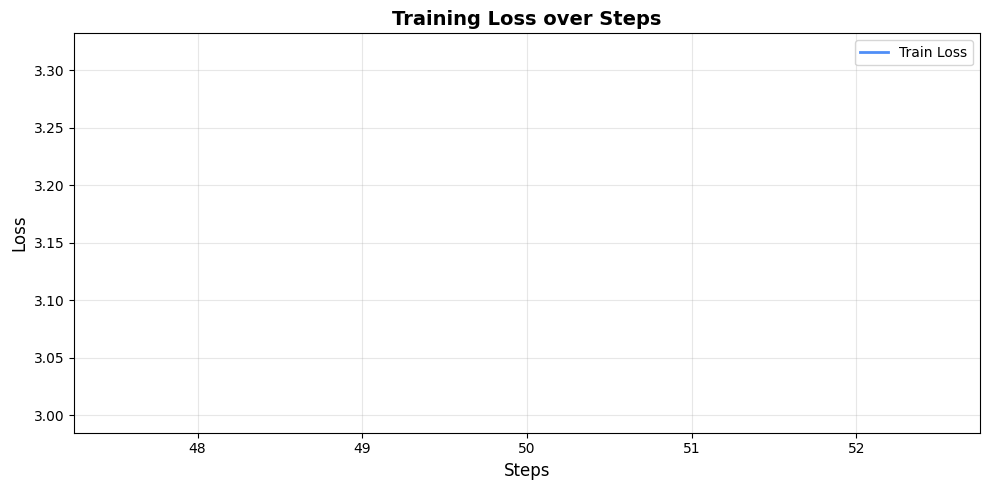

Saved: train_loss.png


In [28]:
#  Plot 1: Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, color="#4F8EF7", linewidth=2, label="Train Loss")
plt.xlabel("Steps",     fontsize=12)
plt.ylabel("Loss",      fontsize=12)
plt.title("Training Loss over Steps", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("train_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: train_loss.png")

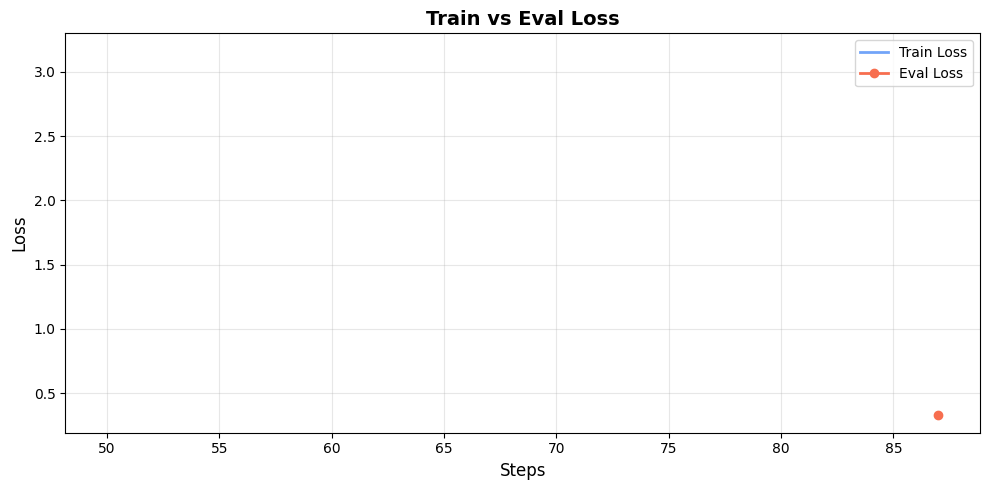

Saved: train_vs_eval_loss.png


In [29]:
#  Plot 2: Train vs Eval Loss
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, color="#4F8EF7", linewidth=2, label="Train Loss",      alpha=0.8)
plt.plot(eval_steps,  eval_loss,  color="#F76E4F", linewidth=2, label="Eval Loss",  marker="o", markersize=6)
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Loss",  fontsize=12)
plt.title("Train vs Eval Loss", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("train_vs_eval_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: train_vs_eval_loss.png")

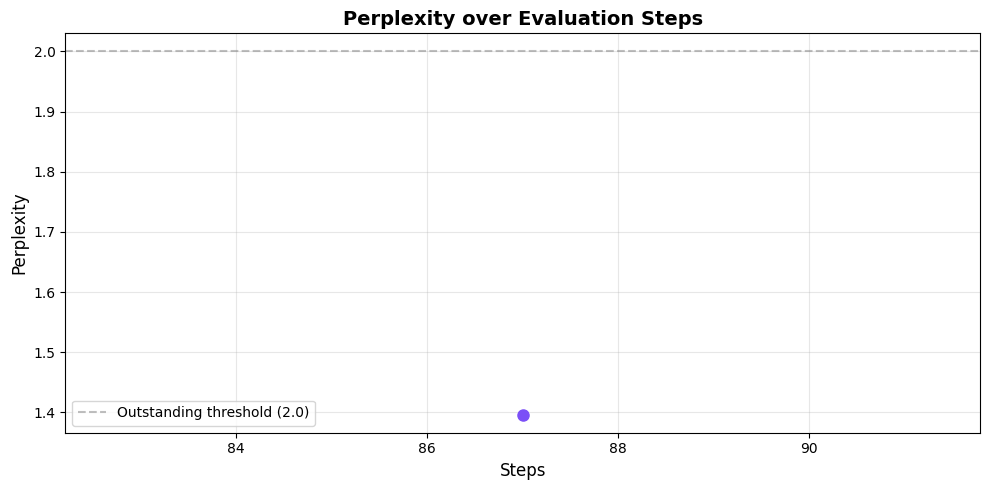

Saved: perplexity.png


In [30]:
#  Plot 3: Perplexity over Eval Steps
plt.figure(figsize=(10, 5))
plt.plot(eval_steps, eval_perplex, color="#7B4FF7", linewidth=2, marker="o", markersize=8)
plt.axhline(y=2.0, color="gray", linestyle="--", alpha=0.5, label="Outstanding threshold (2.0)")
plt.xlabel("Steps",       fontsize=12)
plt.ylabel("Perplexity",  fontsize=12)
plt.title("Perplexity over Evaluation Steps", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("perplexity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: perplexity.png")

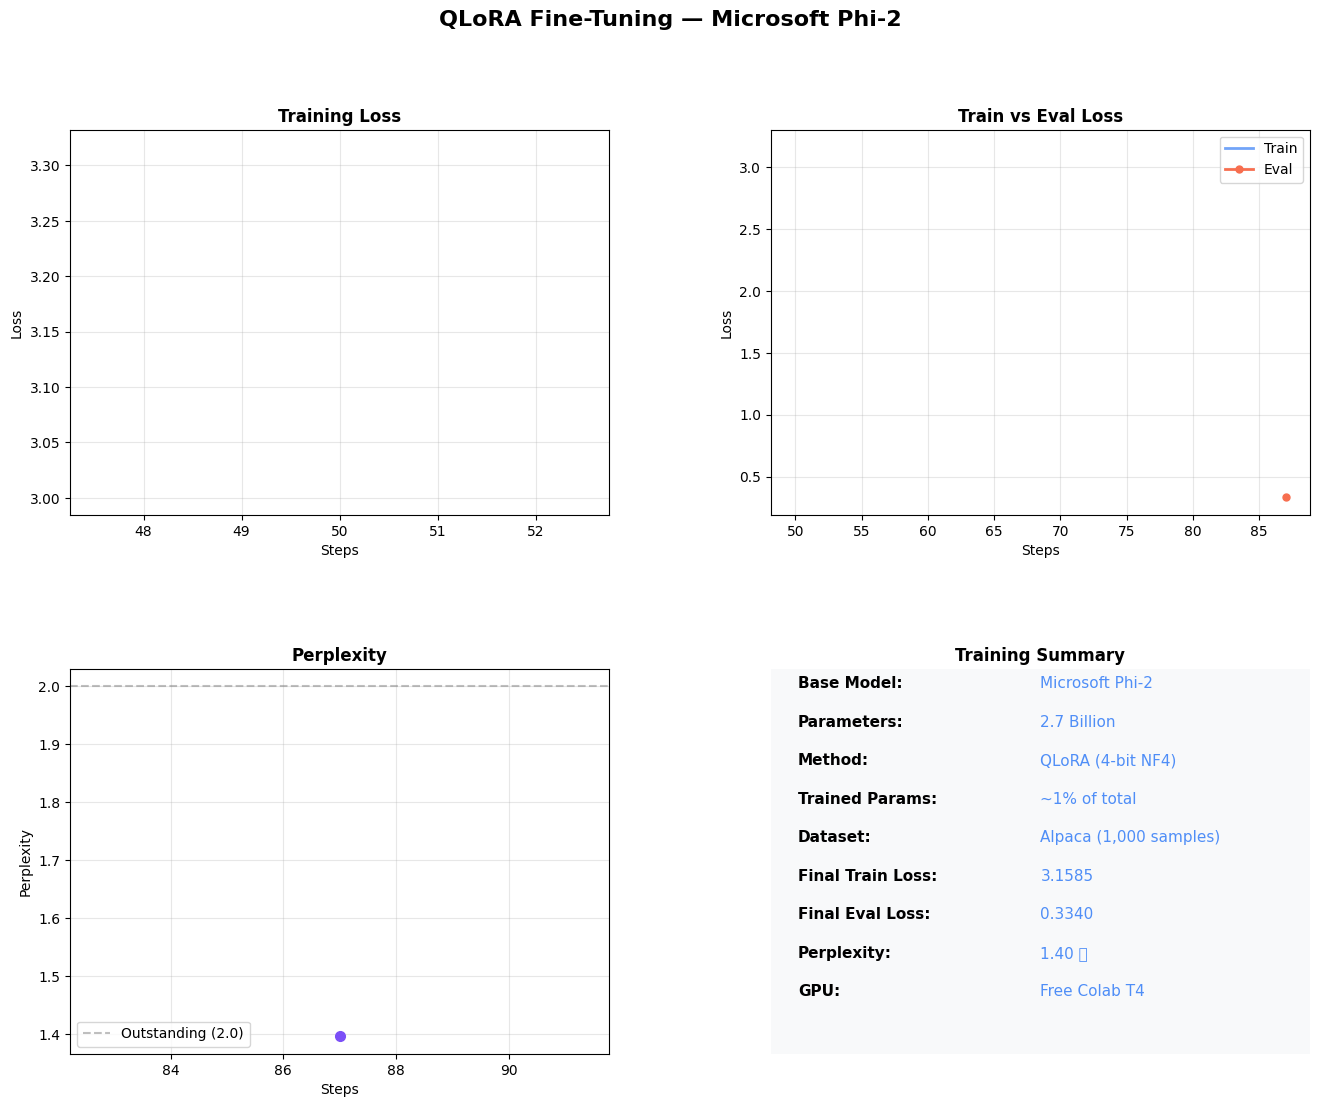

Saved: training_dashboard.png


In [31]:
#  Plot 4: Summary Dashboard (all 3 in one image)
fig = plt.figure(figsize=(16, 12))
fig.suptitle("QLoRA Fine-Tuning — Microsoft Phi-2", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# Top left — Train loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(train_steps, train_loss, color="#4F8EF7", linewidth=2)
ax1.set_title("Training Loss",  fontweight="bold")
ax1.set_xlabel("Steps")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

# Top right — Train vs Eval
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(train_steps, train_loss, color="#4F8EF7", linewidth=2, label="Train",  alpha=0.8)
ax2.plot(eval_steps,  eval_loss,  color="#F76E4F", linewidth=2, label="Eval",   marker="o", markersize=5)
ax2.set_title("Train vs Eval Loss", fontweight="bold")
ax2.set_xlabel("Steps")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom left — Perplexity
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(eval_steps, eval_perplex, color="#7B4FF7", linewidth=2, marker="o", markersize=7)
ax3.axhline(y=2.0, color="gray", linestyle="--", alpha=0.5, label="Outstanding (2.0)")
ax3.set_title("Perplexity", fontweight="bold")
ax3.set_xlabel("Steps")
ax3.set_ylabel("Perplexity")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Bottom right — Final metrics summary card
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
metrics_text = [
    ("Base Model",          "Microsoft Phi-2"),
    ("Parameters",          "2.7 Billion"),
    ("Method",              "QLoRA (4-bit NF4)"),
    ("Trained Params",      "~1% of total"),
    ("Dataset",             "Alpaca (1,000 samples)"),
    ("Final Train Loss",    f"{train_loss[-1]:.4f}"),
    ("Final Eval Loss",     f"{eval_loss[-1]:.4f}"),
    ("Perplexity",          f"{eval_perplex[-1]:.2f} ✅"),
    ("GPU",                 "Free Colab T4"),
]
y_pos = 0.95
for label, value in metrics_text:
    ax4.text(0.05, y_pos, f"{label}:",  fontsize=11, fontweight="bold",  transform=ax4.transAxes)
    ax4.text(0.50, y_pos, value,        fontsize=11, color="#4F8EF7",    transform=ax4.transAxes)
    y_pos -= 0.10

ax4.set_title("Training Summary", fontweight="bold")
ax4.add_patch(plt.Rectangle((0, 0), 1, 1, fill=True, color="#f8f9fa", transform=ax4.transAxes, zorder=-1))

plt.savefig("training_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_dashboard.png")

# How to load Fined-Tuned model later?

In [ ]:
# f How to reload your fine-tuned model in a new session

from peft import PeftModel

# Step 1: Load the base model (quantized)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Step 2: Load your LoRA adapter on top
loaded_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
loaded_tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)

print("Fine-tuned model reloaded successfully.")